<a href="https://colab.research.google.com/github/FinestMaximus/mrkt_screener/blob/main/Screening_Stocks.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Getting Requirements**

In [ ]:
! pip install matplotlib yfinance pandas mplfinance marketprofile plotly

# **Imports**

In [7]:
from datetime import datetime, timedelta

import matplotlib.pyplot as plt

import plotly.express as px
import plotly.graph_objects as go

import mplfinance as mpf
import numpy as np
import pandas as pd
import pandas_datareader as pdr
import yfinance as yf
from IPython.display import Markdown, display
from plotly.subplots import make_subplots

from market_profile import MarketProfile


# **Initial Companies**

In [8]:
companies = ['AMZN', 'GOOG', 'WMT', 'TSLA', 'META', 'NVDA', 'GOLD', 'GSAT', 'AMD',
             'ASML', 'BHP', 'NFLX', 'AAPL', 'AMUN.PA', 'STM', 'LUV', 'TKA.DE', 'IFX.DE',
             'ERA.PA', 'VK.PA', 'MTTR', 'EDF', 'PLUG', 'ASTR', 'NIO', 'LCID', 'SGML', 'U',
             'OKTA', 'SSSS', 'PANW', 'TDOC', 'DARK.L', 'PL', 'IRDM', 'JBLU', 'BTC-USD', 'ETH-USD',
             'DOGE-USD', 'TSM', 'FSLR', 'RAYS', 'ICLN', 'ENB', 'NEE', 'ALB', 'DIS', 'TMUS',
             'VZ', 'CMCSA', 'T', 'NTES', 'AMX', 'SPIR', 'ASTS', 'SPCE', 'LUNR', 'LLAP', 'RKLB',
             'STLA', 'MSFT']

# '2222.SR'ARAMCO

# **Parametters**

In [52]:
interval_dates = '3mo' ### each candle is a quarter
days_history = 365*3 ### looking 5 years back, and 5 years forward
eps_threshold = 5 ### interested in high revenue companies

# **Data fetching and preparation**

In [53]:
def fetch_historical_data(ticker, start_date, end_date, period=None, interval=interval_dates):
    try:
        if period:
            data = ticker.history(period=period, interval=interval)
        else:
            data = ticker.history(start=start_date, end=end_date, interval=interval)
        return data
    except Exception as e:
        print(f"Error fetching data for {ticker}: {e}")
        return pd.DataFrame()  # Return an empty DataFrame

def fetch_data(companies):
    tickers = yf.Tickers(' '.join(companies))
    start_date_str, end_date_str = get_date_range()
    metrics = {
        'eps_values': [],
        'pe_values': [],
        'market_caps': [],
        'peg_values':[],
        'ps_values':[],
        'pb_values':[],
        'company_labels': [],
        'price_diff': {}
    }
    industries = classify_by_industry(tickers)

    price_diff = calculate_price_diff(companies)
    metrics['price_diff'] = price_diff

    for company in companies:
        ticker = tickers.tickers[company]
        data = fetch_historical_data(ticker, start_date_str, end_date_str)
        if not data.empty:
            populate_metrics(ticker, metrics)

    return industries, metrics

def calculate_price_diff(companies):
    tickers = yf.Tickers(' '.join(companies))
    price_diff = {}  # Store price difference info here

    for company in companies:
        ticker = tickers.tickers[company]
        hist = fetch_historical_data(ticker, None, None, period="1y")
        if not hist.empty:
            today_price = hist['Close'].iloc[-1]
            high_52week = max(hist['High'])
            low_52week = min(hist['Low'])
            high_percent_diff = ((today_price - high_52week) / high_52week) * 100
            low_percent_diff = ((today_price - low_52week) / low_52week) * 100
            price_diff[company] = {'high_diff': -1 * high_percent_diff, 'low_diff': low_percent_diff}

    return price_diff

def populate_metrics(ticker, metrics):
    stock_info = ticker.info
    eps = stock_info.get('trailingEps', 0)
    pe = stock_info.get('trailingPE', 0)
    peg = stock_info.get('pegRatio', 0)
    ps = stock_info.get('priceToSalesTrailing12Months', 0)
    pb = stock_info.get('priceToBook', 0)
    market_cap = stock_info.get('marketCap', 0)

    metrics['eps_values'].append(eps)
    metrics['pe_values'].append(pe)
    metrics['peg_values'].append(peg)
    metrics['ps_values'].append(ps)
    metrics['pb_values'].append(pb)
    metrics['market_caps'].append(market_cap)
    metrics['company_labels'].append(ticker.ticker)

def get_date_range(days_back=days_history):
    end_date = datetime.now()
    start_date = end_date - timedelta(days=days_back)
    return start_date.strftime('%Y-%m-%d'), end_date.strftime('%Y-%m-%d')

def classify_by_industry(tickers):
    industries = {}
    for ticker in tickers.tickers.values():
        try:
            sector = ticker.info['sector']
        except KeyError:
            continue
        industries.setdefault(sector, []).append(ticker)
    return industries

def calculate_market_profile(data):
    mp = MarketProfile(data)
    mp_slice = mp[data.index.min():data.index.max()]

    # Access the attributes you're interested in
    va_high, va_low = mp_slice.value_area
    poc_price = mp_slice.poc_price  # Point of control price
    profile_range = mp_slice.profile_range

    return va_high, va_low, poc_price, profile_range

def plot_sector_distribution_interactive(industries):
    # Calculate total tickers per sector
    sector_counts = {sector: len(tickers) for sector, tickers in industries.items()}

    # Data for plotting
    labels = list(sector_counts.keys())
    sizes = list(sector_counts.values())

    # Create the pie chart
    fig = go.Figure(data=[go.Pie(labels=labels, values=sizes, hole=.3)])

    # Customizing the plot
    fig.update_layout(
        title_text="Interactive Ticker Distribution by Sector",
        # Add annotations in the center of the donut pies.
        annotations=[dict(text='Sectors', x=0.50, y=0.5, font_size=20, showarrow=False)]
    )

    # Show plot
    fig.show()

start_date_str, end_date_str = get_date_range()
industries, metrics = fetch_data(companies)

# **Scatter Plots**

In [54]:
def plot_combined_interactive(metrics):
    # Extract data for all plots
    company_labels = metrics['company_labels']  # Already in the script
    eps_values = metrics['eps_values']
    high_diffs = [metrics['price_diff'][company]['high_diff'] for company in company_labels]
    low_diffs = [metrics['price_diff'][company]['low_diff'] for company in company_labels]
    market_caps = metrics['market_caps']  # Assuming this is in USD
    pb_values = metrics['pb_values']
    pe_values = metrics['pe_values']
    peg_values = metrics['peg_values']
    ps_values = metrics['ps_values']

    # Normalize PEG sizes for visualization, keep PEG relevant calculation (normalize step)
    peg_min = min(peg_values)
    peg_max = max(peg_values)
    norm_peg_sizes = [(peg-peg_min)/(peg_max-peg_min)*30+10 for peg in peg_values]  # Use this for Plot 3

    # Create a 1x3 subplot layout
    fig = make_subplots(rows=1, cols=3, subplot_titles=("Price Difference % Over the Last Year", "EPS vs P/E Ratio", "P/B vs P/S Ratios"))

    # Assign a unique color for each company
    colors = {company: f'hsl({(i / len(company_labels) * 360)},100%,50%)' for i, company in enumerate(company_labels)}

    # Use legendgroup to group traces of the same stock
    for i, company in enumerate(company_labels):  # Ensuring alphabetical order through company_labels
        legendgroup = f"group_{company}"

        # Plot 1: Price Difference
        fig.add_trace(go.Scatter(x=[high_diffs[i]], y=[low_diffs[i]], mode='markers+text', text=[company],
                                 marker=dict(size=10, color=colors[company]), legendgroup=legendgroup,
                                 name=company),  # Use 'name' for the legend entry
                      row=1, col=1)

        # Plot 2: EPS vs P/E Ratio
        idx = company_labels.index(company)  # Using index to keep track of the correct company
        marker_size = max(market_caps[idx] / max(market_caps) * 50, 5)
        fig.add_trace(go.Scatter(x=[eps_values[idx]], y=[pe_values[idx]], mode='markers+text', text=[company],
                                 marker=dict(size=marker_size, color=colors[company]), legendgroup=legendgroup,
                                 showlegend=False),  # Hide legend for this to avoid duplicates
                      row=1, col=2)

        # Plot 3: P/B vs P/S with normalized PEG as Marker Size
        marker_size = norm_peg_sizes[idx]  # No need for calculations here, directly use norm_peg_sizes
        fig.add_trace(go.Scatter(x=[pb_values[idx]], y=[ps_values[idx]], mode='markers+text', text=[company],
                                 marker=dict(size=marker_size, color=colors[company]), legendgroup=legendgroup,
                                 hoverinfo='text', hovertext=f"PEG: {peg_values[idx]:.2f}", showlegend=False),
                      row=1, col=3)

    # Update axes titles, ensuring consistency in nomenclature and ordering
    titles = [("High Diff (%)", "Low Diff (%)"), ("EPS", "P/E Ratio"), ("P/B Ratio", "P/S Ratio")]
    for col, (x_title, y_title) in enumerate(titles, start=1):
        fig.update_xaxes(title_text=x_title, row=1, col=col)
        fig.update_yaxes(title_text=y_title, row=1, col=col)

    # Layout adjustments for readability and aesthetics
    fig.update_layout(height=600, width=1800, title_text="Comprehensive Company Metrics Visualization", plot_bgcolor='rgba(0,0,0,0)', legend_title_text='Company')
    fig.update_traces(textposition='top center')

    # Showing the combined plot
    fig.show()


# Plot P/E & EPS

In [55]:
plot_combined_interactive(metrics)

In [56]:
plot_sector_distribution_interactive(industries)

# **Filters**

In [57]:
def filter_companies(metrics, eps_threshold=None):
    filtered_data = {
        'company': [],
        'eps': [],
        'pe': [],
        'ps': [],
        'pb': [],
        'peg': [],
        'high_diff': [],
        'low_diff': []
    }

    for i, label in enumerate(metrics['company_labels']):
        eps = metrics['eps_values'][i]
        pe = metrics['pe_values'][i]
        ps = metrics['ps_values'][i]
        pb = metrics['pb_values'][i]
        peg = metrics['peg_values'][i]
        high_diff = metrics['price_diff'][label]['high_diff']
        low_diff = metrics['price_diff'][label]['low_diff']

        # Apply filtering based solely on the eps_threshold
        if eps_threshold is not None and peg is not None and eps > eps_threshold and peg <= 1:
            # Criteria met, proceed with this company
            print(f"Processing {metrics['company_labels'][i]}...") # Placeholder for further processing

        else:
            # If any condition is false, this company is skipped
            print(f"Skipping {metrics['company_labels'][i]} due to criteria not met.")
            continue  # Explicitly stating continue for clarity, though it's the loop's next step anyway

        # If the company meets the EPS criteria, add data to the filtered_data dict
        filtered_data['company'].append(label)
        filtered_data['eps'].append(eps)
        filtered_data['pe'].append(pe)
        filtered_data['ps'].append(pe)
        filtered_data['pb'].append(pe)
        filtered_data['peg'].append(pe)
        filtered_data['high_diff'].append(high_diff)
        filtered_data['low_diff'].append(low_diff)

    # Convert to DataFrame
    df = pd.DataFrame(filtered_data)

    # Add an 'e/p' ratio column for identifying undervalued companies
    df['e/p'] = df['eps'] / df['pe']

    # Sort DataFrame by P/E ratio in ascending order to show companies with lowest P/E on top
    df_sorted = df.sort_values(by='pe', ascending=True)

    return df_sorted

filtered_companies_df = filter_companies(metrics, eps_threshold)
filtered_company_symbols = filtered_companies_df['company'].tolist()

start_date_str, end_date_str = get_date_range()
industries_filtered, metrics_filtered = fetch_data(filtered_company_symbols)

Skipping AMZN due to criteria not met.
Skipping GOOG due to criteria not met.
Skipping WMT due to criteria not met.
Skipping TSLA due to criteria not met.
Processing META...
Skipping NVDA due to criteria not met.
Skipping GOLD due to criteria not met.
Skipping GSAT due to criteria not met.
Skipping AMD due to criteria not met.
Skipping ASML due to criteria not met.
Skipping BHP due to criteria not met.
Skipping NFLX due to criteria not met.
Skipping AAPL due to criteria not met.
Skipping AMUN.PA due to criteria not met.
Skipping STM due to criteria not met.
Skipping LUV due to criteria not met.
Skipping TKA.DE due to criteria not met.
Skipping IFX.DE due to criteria not met.
Skipping ERA.PA due to criteria not met.
Skipping VK.PA due to criteria not met.
Skipping MTTR due to criteria not met.
Skipping EDF due to criteria not met.
Skipping PLUG due to criteria not met.
Skipping ASTR due to criteria not met.
Skipping NIO due to criteria not met.
Skipping LCID due to criteria not met.
Ski

# **Plotting charts**


In [58]:
# Function to get the EPS and PE for a given ticker
def get_eps_pe_pb_ps_peg(ticker):
    try:
        if ticker.ticker in metrics['company_labels']:
            index = metrics['company_labels'].index(ticker.ticker)
            eps = metrics['eps_values'][index]
            pe = metrics['pe_values'][index]
            ps = metrics['ps_values'][index]
            pb = metrics['pb_values'][index]
            peg = metrics['peg_values'][index]

            return eps, pe, ps, pb, peg
        else:
            # This line is crucial as it will inform us if the ticker was not found in our labels list.
            print(f"Ticker '{ticker.ticker}' not found in the labels list.")
            return None, None
    except Exception as e:
        # Catching any other potential error to understand what might have gone wrong.
        print(f"An error occurred: {e}")
        return None, None

# Visualization Mock-up: Just showcasing one ticker as an example
def plot_with_volume_profile(ticker, start_date, end_date):
    # Fetching the historical data
    data = fetch_historical_data(ticker, start_date, end_date)
    eps, pe, ps, pb, peg = get_eps_pe_pb_ps_peg(ticker)

    if not data.empty:
        # Calculate the market profile
        va_high, va_low, poc_price, _ = calculate_market_profile(data)

        # Creating lines as Pandas Series to ensure compatibility
        poc_line = pd.Series(poc_price, index=data.index)
        va_high_line = pd.Series(va_high, index=data.index)
        va_low_line = pd.Series(va_low, index=data.index)

        # Annotations for Value Area and POC
        apds = [mpf.make_addplot(poc_line, type='line', color='red', linestyle='dashed', width=3),
                mpf.make_addplot(va_high_line, type='line', color='blue', linestyle='dashed', width=0.7),
                mpf.make_addplot(va_low_line, type='line', color='blue', linestyle='dashed', width=0.7)]

        title = f"{ticker.info['shortName']}\n\n\n EPS={eps}, P/E={pe}, P/S={ps}, P/B={pb}, PEG ratio={peg}\n Price of Control in Red, and Value Area in Blue\n Low P/x means company is undervalued \na High EPS means company is profitable\n PEG is typically lower than 1.0\n\n\n"

        # Plotting the chart with MPLFinance
        mpf.plot(data, type="candle", addplot=apds, title=title, style="yahoo", volume=True, show_nontrading=False)
    else:
        print(f"No data found for {ticker.ticker} in the given date range.")

from IPython.display import display, Markdown
import matplotlib.pyplot as plt

def plot_sector_charts(industries, start_date, end_date):
    for sector, ticker_list in industries.items():
        # Display sector heading
        display(Markdown(f"## Sector: {sector}"))

        # Iterate through the list of ticker objects for each sector
        for ticker in ticker_list:
            # Ensure `plot_with_volume_profile` is capable of extracting the ticker symbol as needed
            plot_with_volume_profile(ticker, start_date, end_date)

        # Ensures that plots from different calls don't overlap
        plt.tight_layout()

    plt.show()


# **Plot Filtered Charts**

## Sector: Consumer Cyclical

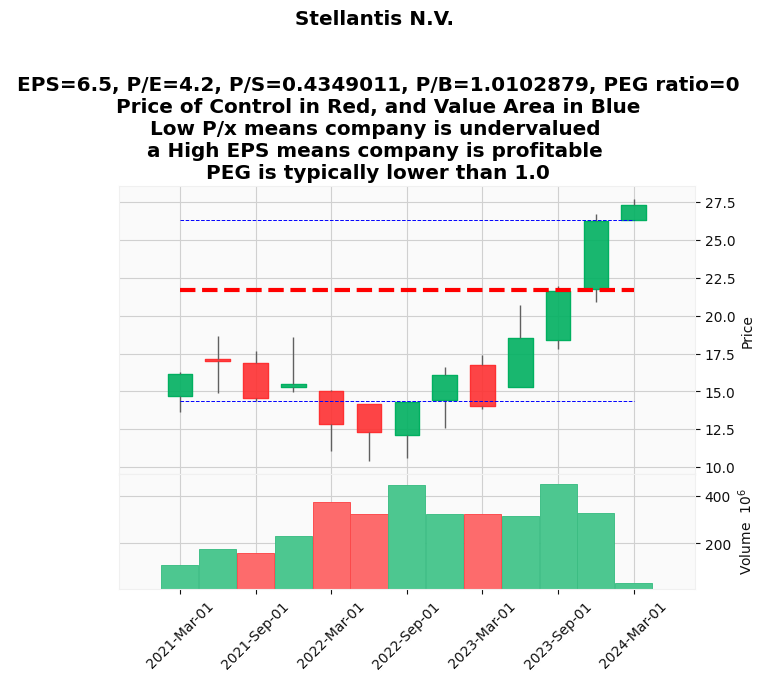

## Sector: Basic Materials

<Figure size 640x480 with 0 Axes>

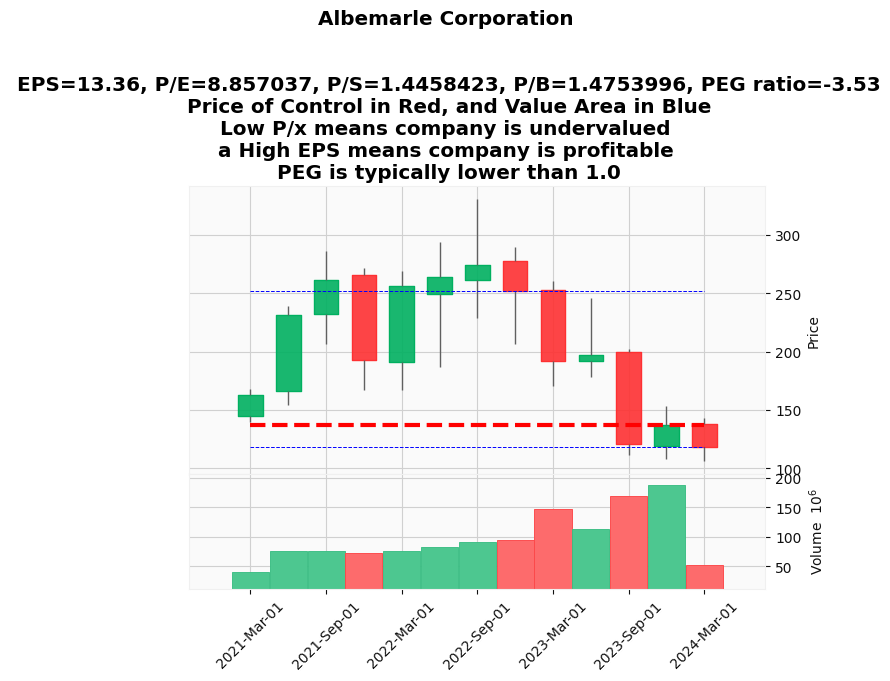

## Sector: Technology

<Figure size 640x480 with 0 Axes>

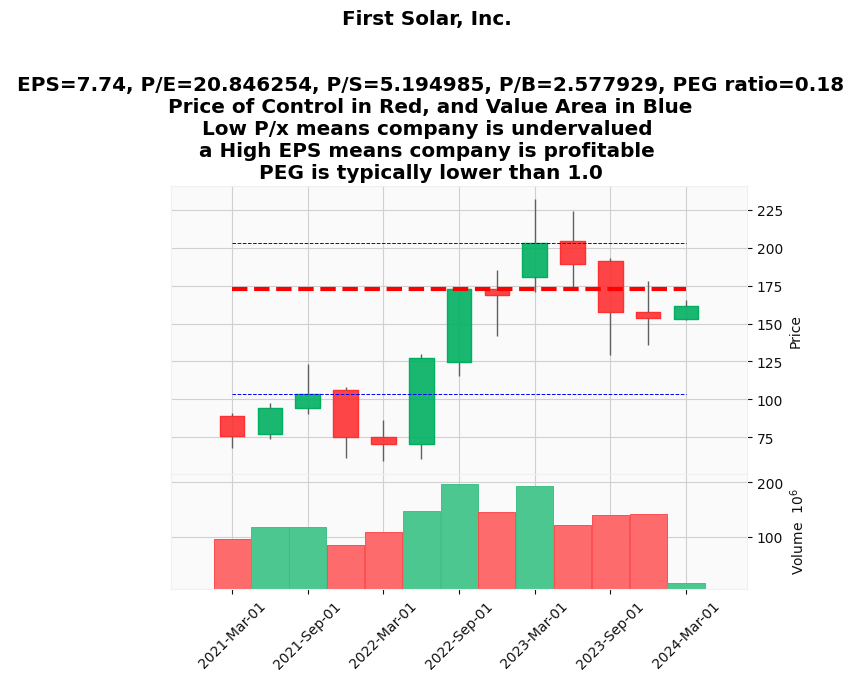

## Sector: Communication Services

<Figure size 640x480 with 0 Axes>

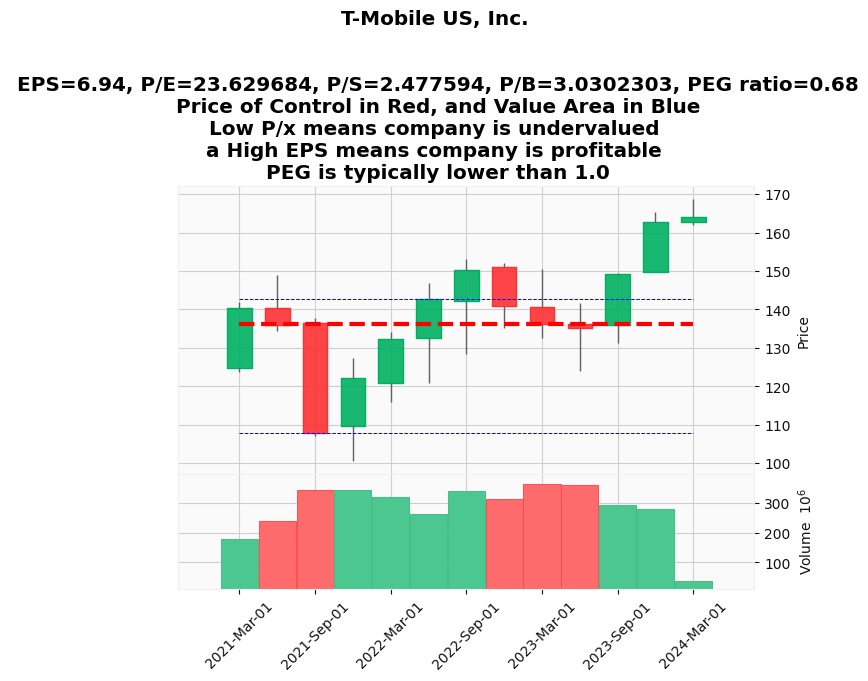

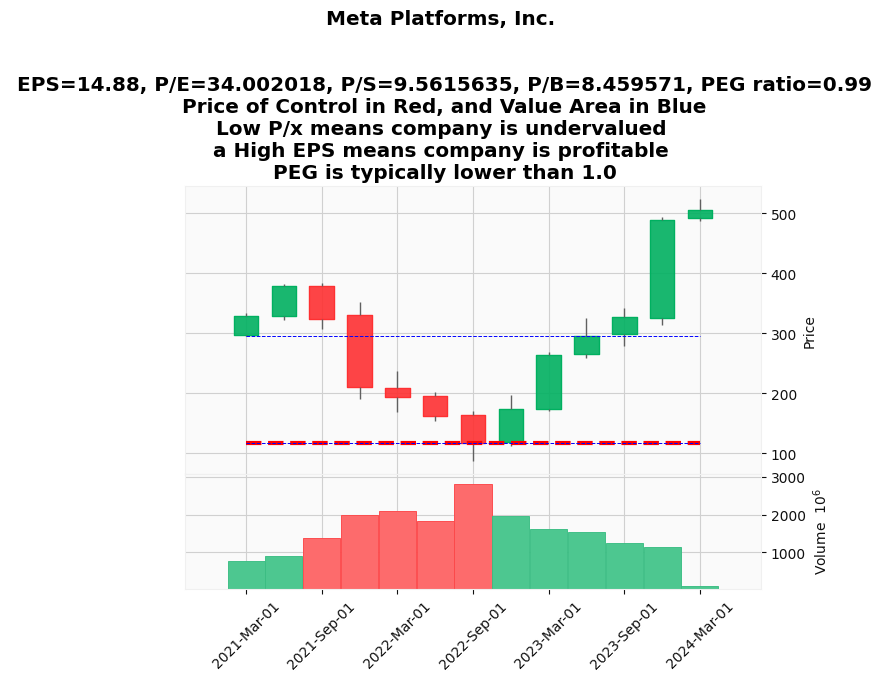

<Figure size 640x480 with 0 Axes>

In [59]:
plot_sector_charts(industries_filtered, start_date_str, end_date_str)